# Exp 8: optimality gaps of heuristic and NPM solvers vs. exact

Each run in exp_8 solves the *same* sampled instance (same perturbed quantities, epsilons, and heterogeneous costs) with three strategies: `exact`, `heuristic_accelerated`, and `network_prioritized`. Because all three share the same instance/parameters within a run, we can compute a true optimality gap for the heuristic and NPM solvers relative to the exact platform profit, rather than relying on each solver's own internal primal-dual `rel_gap`.

In [1]:
from pathlib import Path
import gzip
import json
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import numpy as np
import seaborn as sns


In [2]:
sns.set_theme(context="paper", style="ticks")

plt.rcParams.update({
    "font.size": 10,
    "axes.labelsize": 10,
    "axes.titlesize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
})


In [3]:
root = Path("../results/exp_8")
jsons = list(root.rglob("*.json.gz"))
print(f"Found {len(jsons)} job files")


Found 196 job files


In [4]:
STRATEGIES = {
    "heuristic": "summary_heuristic",
    "npm": "summary_npm",
}

rows = []

for file in jsons:
    with gzip.open(file, "rt", encoding="utf-8") as f:
        payload = json.load(f)

    job_id = payload["experiment_metadata"]["job_id"]

    for run in payload["runs"]:
        metadata = run["metadata"]
        summary_exact = run["summary_exact"]

        snapshot = summary_exact["instance_snapshot"]
        n_farmers = len(snapshot["farmers"])
        n_intermediaries = len(snapshot["intermediaries"])

        exact_profit = summary_exact["platform_solve_result"]["primary_result"]["platform_profit"]
        exact_time = summary_exact["total_time"]

        for strategy_label, summary_key in STRATEGIES.items():
            summary = run[summary_key]
            profit = summary["platform_solve_result"]["primary_result"]["platform_profit"]

            # Platform profit can be negative (~6% of runs here), so we normalize
            # by |exact_profit| rather than exact_profit itself -- otherwise the sign
            # flips and a strategy that loses to exact looks like it "beat" it.
            abs_gap = exact_profit - profit
            rel_gap = abs_gap / abs(exact_profit) if exact_profit != 0 else np.nan

            rows.append({
                "job_id": job_id,
                "run_index": metadata["run_index"],
                "instance_file": metadata["instance_file"],
                "n_farmers": n_farmers,
                "n_intermediaries": n_intermediaries,
                "strategy": strategy_label,
                "exact_profit": exact_profit,
                "profit": profit,
                "abs_gap": abs_gap,
                "rel_gap": rel_gap,
                "exact_time": exact_time,
                "time": summary["total_time"],
                "total_oracle_calls": summary["total_oracle_calls"],
                "internal_rel_gap": summary["rel_gap"],
            })

df = pd.DataFrame(rows)
df.shape


(3918, 14)

In [5]:
# sanity check: exact should (weakly) dominate both heuristics; negative gaps
# would indicate a bug either in the heuristics or in the exact solver.
print("Negative gaps (profit(strategy) > profit(exact)):")
print(df.query("rel_gap < -1e-6"))

df.groupby("strategy")["rel_gap"].describe()


Negative gaps (profit(strategy) > profit(exact)):
Empty DataFrame
Columns: [job_id, run_index, instance_file, n_farmers, n_intermediaries, strategy, exact_profit, profit, abs_gap, rel_gap, exact_time, time, total_oracle_calls, internal_rel_gap]
Index: []


,count,mean,std,min,25%,50%,75%,max
strategy,,,,,,,,
heuristic,1959.0,-1.792469e-15,1.113419e-13,-1.811926e-12,0.000000e+00,0.0,0.000000e+00,1.943979e-12
npm,1959.0,7.108565e-03,5.461784e-02,-1.130889e-11,-1.162094e-14,0.0,1.839128e-14,1.218551e+00


In [6]:
thresholds = [1e-6, 1e-3, 1e-2, 0.05, 0.1]

threshold_table = pd.DataFrame({
    f"gap > {t:.1%}": df.groupby("strategy")["rel_gap"].apply(lambda s, t=t: (s > t).mean())
    for t in thresholds
})
threshold_table


,gap > 0.0%,gap > 0.1%,gap > 1.0%,gap > 5.0%,gap > 10.0%
strategy,,,,,
heuristic,0.000000,0.000000,0.00000,0.000000,0.00000
npm,0.054109,0.053599,0.04441,0.028586,0.02144


The accelerated heuristic matches the exact platform profit in every one of the 1,959 runs (gaps are pure floating-point noise, ~1e-12). NPM has a nonzero gap in about 5.4% of runs, occasionally quite large (max ~122%). Because the distribution is this zero-inflated, a boxplot of the raw gap is dominated by numerical noise near zero and its axis labels become unreadable -- the cell below uses a symlog y-axis so both the near-zero bulk and the large-outlier tail are visible on the same plot.

## NPM optimality gap vs. exact

Focusing on NPM alone (the heuristic is omitted here since it is essentially always at 0%).

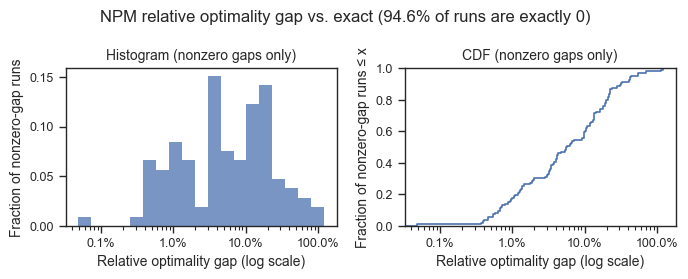

In [7]:
npm_df = df.query("strategy == 'npm'").copy()
# clip tiny negative floating-point noise (solver ties) to 0
npm_df["rel_gap"] = npm_df["rel_gap"].clip(lower=0)

zero_frac = (npm_df["rel_gap"] <= 1e-9).mean()
npm_nonzero = npm_df.query("rel_gap > 1e-9")

fig, axes = plt.subplots(1, 2, figsize=(7, 2.8))

sns.histplot(
    data=npm_nonzero,
    x="rel_gap",
    stat="probability",
    bins=np.logspace(np.log10(npm_nonzero["rel_gap"].min()), np.log10(npm_nonzero["rel_gap"].max()), 20),
    color=sns.color_palette()[0],
    ax=axes[0],
)
axes[0].set_xscale("log")
axes[0].xaxis.set_major_formatter(PercentFormatter(xmax=1, decimals=1))
axes[0].set_xlabel("Relative optimality gap (log scale)")
axes[0].set_ylabel("Fraction of nonzero-gap runs")
axes[0].set_title("Histogram (nonzero gaps only)")

sns.ecdfplot(
    data=npm_nonzero,
    x="rel_gap",
    color=sns.color_palette()[0],
    ax=axes[1],
)
axes[1].set_xscale("log")
axes[1].xaxis.set_major_formatter(PercentFormatter(xmax=1, decimals=1))
axes[1].set_xlabel("Relative optimality gap (log scale)")
axes[1].set_ylabel("Fraction of nonzero-gap runs ≤ x")
axes[1].set_title("CDF (nonzero gaps only)")

fig.suptitle(f"NPM relative optimality gap vs. exact ({zero_frac:.1%} of runs are exactly 0)")
plt.tight_layout()
plt.savefig("../figures/exp_8/npm_opt_gap.png", bbox_inches="tight", dpi=300)
plt.show()


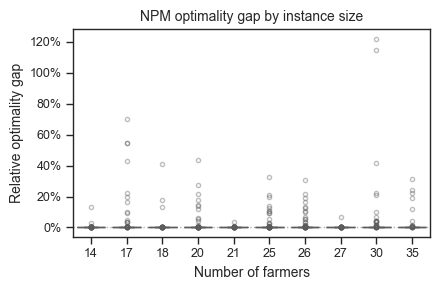

In [8]:
plt.figure(figsize=(4.5, 3))

ax = sns.boxplot(
    data=npm_df,
    x="n_farmers",
    y="rel_gap",
    color=sns.color_palette()[1],
    showfliers=True,
    flierprops={"marker": "o", "alpha": 0.4, "markersize": 3},
)

ax.axhline(0, color="black", linestyle="dotted", linewidth=1, alpha=0.3, zorder=0)
ax.yaxis.set_major_formatter(PercentFormatter(xmax=1))
ax.set_xlabel("Number of farmers")
ax.set_ylabel("Relative optimality gap")
ax.set_title("NPM optimality gap by instance size")

plt.tight_layout()
plt.savefig("../figures/exp_8/npm_opt_gap_by_size.png", bbox_inches="tight", dpi=300)
plt.show()


### Is the 94.6%-at-zero number meaningful, or is it just "NPM solved the root and stopped"?

NPM's loop (`search_strategies.py::solve_npm`) evaluates candidates `k=0,1,2,...` and each `k` that reaches the pricing step costs exactly one call to `optimizer.initialize_branch` (the matching/VRP oracle), which increments `total_oracle_calls`. `stabilize_final_solution=True` (used in exp_8) always adds one extra oracle call at the very end regardless of strategy. So a run that essentially only evaluates the `k=0` candidate (the plain minimum-cost/efficient matching) before the `U_k` bound prunes everything else should show up as a *small, near-constant* `total_oracle_calls` -- and a run that actually explores several priority levels should show a visibly larger count. We use `total_oracle_calls` as a (rough, but directly measurable) proxy for "did NPM do anything beyond the root candidate."

In [9]:
oracle_call_stats = npm_df.groupby("total_oracle_calls")["rel_gap"].agg(["count", "mean", "max"])
oracle_call_stats["count"] = oracle_call_stats["count"].astype(int)
oracle_call_stats


,count,mean,max
total_oracle_calls,,,
3,618,2.331593e-14,3.060686e-12
4,59,1.029834e-14,1.216102e-13
5,258,1.878907e-03,1.761529e-01
6,444,6.874464e-03,6.994669e-01
7,349,1.223000e-02,5.430615e-01
8,172,1.268707e-02,3.139640e-01
9,56,7.032521e-02,1.218551e+00
10,3,9.408012e-15,2.822404e-14


This confirms the concern directly: `total_oracle_calls` of 3 or 4 (the smallest observed values -- root candidate evaluated, then immediately pruned) have a mean/max gap of essentially exactly 0 (~1e-14, floating-point noise), and account for 677 of the 1,959 runs (~34.6%). These are "trivial" in exactly the sense suspected -- NPM never got past evaluating (and keeping) the plain minimum-cost matching, so of course it matches the true optimum: at `k=0` the true optimum coincides with the efficient matching whenever nothing forces a costlier intermediary in for stability. From `total_oracle_calls=5` onward (NPM actually explored past the root), both the mean and max gap climb monotonically, up to the max ~122% gap at `total_oracle_calls=9`. We isolate the nontrivial subset below and recompute the gap distribution restricted to it.

In [10]:
# data-driven cutoff: the smallest oracle-call counts with (essentially) zero gap
TRIVIAL_MAX_ORACLE_CALLS = 4

npm_nontrivial = npm_df.query("total_oracle_calls > @TRIVIAL_MAX_ORACLE_CALLS").copy()
trivial_frac = 1 - len(npm_nontrivial) / len(npm_df)

print(f"Trivial (root-only) runs: {trivial_frac:.1%} of NPM runs ({len(npm_df) - len(npm_nontrivial)} of {len(npm_df)})")
print(f"Nontrivial runs: {len(npm_nontrivial)}")
print()

nontrivial_thresholds = pd.DataFrame({
    f"gap > {t:.1%}": [(npm_nontrivial["rel_gap"] > t).mean()]
    for t in [1e-6, 1e-3, 1e-2, 0.05, 0.1]
}, index=["npm (nontrivial only)"])
nontrivial_thresholds


Trivial (root-only) runs: 34.6% of NPM runs (677 of 1959)
Nontrivial runs: 1282



,gap > 0.0%,gap > 0.1%,gap > 1.0%,gap > 5.0%,gap > 10.0%
npm (nontrivial only),0.082683,0.081903,0.067863,0.043682,0.032761


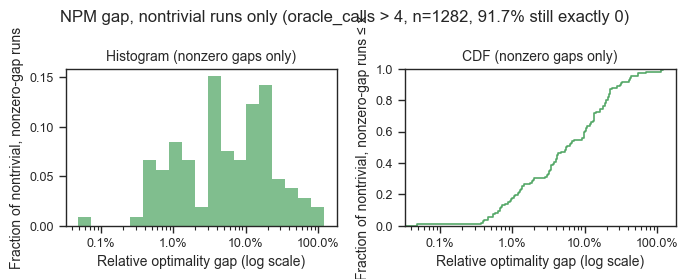

In [11]:
zero_frac_nontrivial = (npm_nontrivial["rel_gap"] <= 1e-9).mean()
nontrivial_nonzero = npm_nontrivial.query("rel_gap > 1e-9")

fig, axes = plt.subplots(1, 2, figsize=(7, 2.8))

sns.histplot(
    data=nontrivial_nonzero,
    x="rel_gap",
    stat="probability",
    bins=np.logspace(np.log10(nontrivial_nonzero["rel_gap"].min()), np.log10(nontrivial_nonzero["rel_gap"].max()), 20),
    color=sns.color_palette()[2],
    ax=axes[0],
)
axes[0].set_xscale("log")
axes[0].xaxis.set_major_formatter(PercentFormatter(xmax=1, decimals=1))
axes[0].set_xlabel("Relative optimality gap (log scale)")
axes[0].set_ylabel("Fraction of nontrivial, nonzero-gap runs")
axes[0].set_title("Histogram (nonzero gaps only)")

sns.ecdfplot(
    data=nontrivial_nonzero,
    x="rel_gap",
    color=sns.color_palette()[2],
    ax=axes[1],
)
axes[1].set_xscale("log")
axes[1].xaxis.set_major_formatter(PercentFormatter(xmax=1, decimals=1))
axes[1].set_xlabel("Relative optimality gap (log scale)")
axes[1].set_ylabel("Fraction of nontrivial, nonzero-gap runs ≤ x")
axes[1].set_title("CDF (nonzero gaps only)")

fig.suptitle(
    f"NPM gap, nontrivial runs only (oracle_calls > {TRIVIAL_MAX_ORACLE_CALLS}, "
    f"n={len(npm_nontrivial)}, {zero_frac_nontrivial:.1%} still exactly 0)"
)
plt.tight_layout()
plt.savefig("../figures/exp_8/npm_opt_gap_nontrivial.png", bbox_inches="tight", dpi=300)
plt.show()


**Revised takeaway**: root-only ("trivial") runs account for 34.6% of all NPM runs and are indeed uninteresting (near-zero gap by construction). But even after excluding them, **91.7% of the remaining 1,282 "nontrivial" runs still land exactly on the true optimum** -- NPM explored past `k=0`, considered costlier candidates for stability, and still recovered the correct answer. So the original 94.6%-at-zero headline number was inflated by ~3 points from trivial cases, but it wasn't *mostly* a root-solving artifact -- NPM's greedy search is still landing on the exact optimum most of the time even when it has to do real work. The nonzero tail (`gap > 0.1%` in 8.2% of nontrivial runs vs. 5.4% overall) is somewhat more concentrated among the nontrivial runs, as expected, since a run that never leaves the root can't fail via the specific mechanism (mis-ranking a zero-history intermediary) identified above.

## A cleaner check: is the *true* optimum different from the efficient (min-cost) matching?

`total_oracle_calls` is a reasonable proxy for "did NPM's own search do anything," but it doesn't directly answer the sharper question: for how many instances does achieving the true optimum actually *require* deviating from the plain minimum-cost matching in the first place? If the true optimum always equals the efficient matching, then any solver that just returns the efficient matching (like NPM's `k=0` candidate) is trivially exact on that instance, regardless of its own search dynamics.

There's an exact field for this rather than needing to diff the `lower_bounds` history: `solve_branch_exact` (`search_strategies.py:664-676`) evaluates the *root* branch (no forced match/unmatch) first and unconditionally records its result as `instance_summary.forced_lower_bound` -- this is exactly `Π^eff`, the true feasible profit of the efficient/min-cost matching (with correct stability payments), computed via the same `sol_type="forced_lower_bound"` solve NPM itself uses for its `k=0` candidate. Since `best_lb` starts at `-inf` and is monotonically non-decreasing, this root value is also always `lower_bounds[0]` -- but comparing `exact_profit` directly to `forced_lower_bound` is exact and avoids relying on how many times `record_summary()` happened to be called (e.g. it can be called again at termination with an unchanged value, so counting *entries* in `lower_bounds` isn't quite right -- counting *distinct* values would work too, but this is more direct).

So: **the true optimum differs from the efficient matching iff `exact_profit - forced_lower_bound > tolerance`.**

In [12]:
forced_lb_rows = []
for file in jsons:
    with gzip.open(file, "rt", encoding="utf-8") as f:
        payload = json.load(f)
    job_id = payload["experiment_metadata"]["job_id"]
    for run in payload["runs"]:
        forced_lb_rows.append({
            "job_id": job_id,
            "run_index": run["metadata"]["run_index"],
            "exact_forced_lower_bound": run["summary_exact"]["forced_lower_bound"],
        })

forced_lb_df = pd.DataFrame(forced_lb_rows)

EXACT_NONTRIVIAL_TOL = 1.0  # currency units; matches BRANCH_PRUNE_TOL in the solver

npm_df = npm_df.merge(forced_lb_df, on=["job_id", "run_index"], how="left")
npm_df["exact_is_nontrivial"] = (
    npm_df["exact_profit"] - npm_df["exact_forced_lower_bound"]
) > EXACT_NONTRIVIAL_TOL

exact_nontrivial_frac = npm_df["exact_is_nontrivial"].mean()
print(f"Fraction of instances where the true optimum beats the efficient matching: {exact_nontrivial_frac:.1%}")
print(f"({npm_df['exact_is_nontrivial'].sum()} of {len(npm_df)} runs)")


Fraction of instances where the true optimum beats the efficient matching: 19.6%
(383 of 1959 runs)


In [13]:
npm_hard = npm_df.query("exact_is_nontrivial").copy()

problem_thresholds = pd.DataFrame({
    f"gap > {t:.1%}": [(npm_hard["rel_gap"] > t).mean()]
    for t in [1e-6, 1e-3, 1e-2, 0.05, 0.1]
}, index=[f"npm (true optimum ≠ efficient matching, n={len(npm_hard)})"])
problem_thresholds


,gap > 0.0%,gap > 0.1%,gap > 1.0%,gap > 5.0%,gap > 10.0%
"npm (true optimum ≠ efficient matching, n=383)",0.276762,0.274151,0.227154,0.146214,0.109661


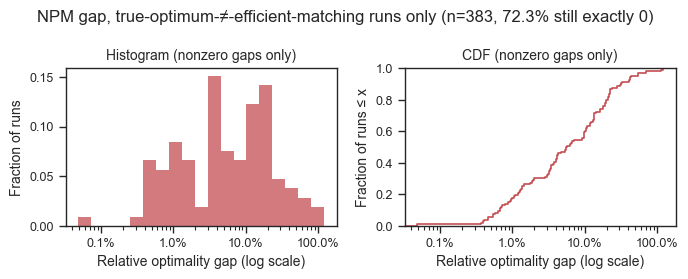

In [14]:
zero_frac_hard = (npm_hard["rel_gap"] <= 1e-9).mean()
hard_nonzero = npm_hard.query("rel_gap > 1e-9")

fig, axes = plt.subplots(1, 2, figsize=(7, 2.8))

sns.histplot(
    data=hard_nonzero,
    x="rel_gap",
    stat="probability",
    bins=np.logspace(np.log10(hard_nonzero["rel_gap"].min()), np.log10(hard_nonzero["rel_gap"].max()), 20),
    color=sns.color_palette()[3],
    ax=axes[0],
)
axes[0].set_xscale("log")
axes[0].xaxis.set_major_formatter(PercentFormatter(xmax=1, decimals=1))
axes[0].set_xlabel("Relative optimality gap (log scale)")
axes[0].set_ylabel("Fraction of runs")
axes[0].set_title("Histogram (nonzero gaps only)")

sns.ecdfplot(
    data=hard_nonzero,
    x="rel_gap",
    color=sns.color_palette()[3],
    ax=axes[1],
)
axes[1].set_xscale("log")
axes[1].xaxis.set_major_formatter(PercentFormatter(xmax=1, decimals=1))
axes[1].set_xlabel("Relative optimality gap (log scale)")
axes[1].set_ylabel("Fraction of runs ≤ x")
axes[1].set_title("CDF (nonzero gaps only)")

fig.suptitle(
    f"NPM gap, true-optimum-≠-efficient-matching runs only "
    f"(n={len(npm_hard)}, {zero_frac_hard:.1%} still exactly 0)"
)
plt.tight_layout()
plt.savefig("../figures/exp_8/npm_opt_gap_hard.png", bbox_inches="tight", dpi=300)
plt.show()


**This is the real number**: restricting to the 383 instances (19.6% of all runs) where the true optimum actually requires deviating from the efficient matching, NPM's nonzero-gap rate jumps from 5.4% (all runs) to **27.7%** -- better than 1 in 4.

The nonzero-gap *count* is identical to the oracle-calls-based cut above (106 runs either way) -- this isn't a coincidence, it's forced by construction: NPM's `k=0` candidate always equals the efficient-matching profit exactly, and `best_lb` only ever improves from there, so `NPM_profit >= efficient_matching_profit` always holds. If the true optimum *equals* the efficient matching, NPM is therefore mathematically guaranteed a zero gap regardless of what its search does afterward -- a nonzero gap is only *possible* on the 383 "hard" instances. What changes here is the denominator: instead of diluting NPM's real failure rate across ~1,600 instances where it literally cannot fail, restricting to instances where failure is possible reveals NPM is right around 72% of the time on the cases that actually test it, not ~95%.

## Overall distribution of relative optimality gaps

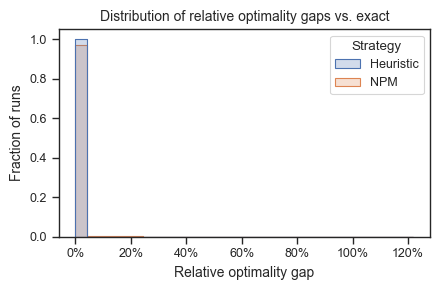

In [15]:
label_mapping = {"heuristic": "Heuristic", "npm": "NPM"}
plot_df = df.assign(Strategy=df["strategy"].map(label_mapping))

plt.figure(figsize=(4.5, 3))

ax = sns.histplot(
    data=plot_df,
    x="rel_gap",
    hue="Strategy",
    stat="probability",
    common_norm=False,
    element="step",
    bins=30,
)

ax.xaxis.set_major_formatter(PercentFormatter(xmax=1))
ax.set_xlabel("Relative optimality gap")
ax.set_ylabel("Fraction of runs")
ax.set_title("Distribution of relative optimality gaps vs. exact")

plt.tight_layout()
plt.savefig("../figures/exp_8/opt_gap_hist.png", bbox_inches="tight", dpi=300)
plt.show()


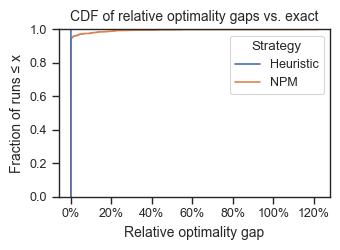

In [16]:
plt.figure(figsize=(3.5, 2.6))

ax = sns.ecdfplot(
    data=plot_df,
    x="rel_gap",
    hue="Strategy",
)

ax.xaxis.set_major_formatter(PercentFormatter(xmax=1))
ax.set_xlabel("Relative optimality gap")
ax.set_ylabel("Fraction of runs \u2264 x")
ax.set_title("CDF of relative optimality gaps vs. exact")

plt.tight_layout()
plt.savefig("../figures/exp_8/opt_gap_ecdf.png", bbox_inches="tight", dpi=300)
plt.show()


## Relative optimality gap by instance size

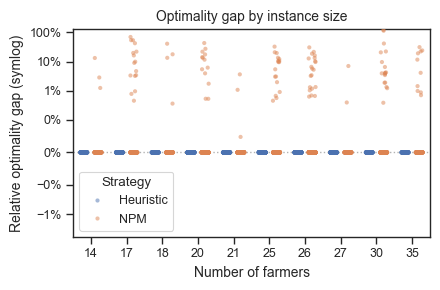

In [17]:
plt.figure(figsize=(4.5, 3))

ax = sns.stripplot(
    data=plot_df,
    x="n_farmers",
    y="rel_gap",
    hue="Strategy",
    dodge=True,
    alpha=0.5,
    size=3,
    jitter=0.2,
)

ax.axhline(0, color="black", linestyle="dotted", linewidth=1, alpha=0.3, zorder=0)
ax.set_yscale("symlog", linthresh=1e-3)
ax.yaxis.set_major_formatter(PercentFormatter(xmax=1))
ax.set_xlabel("Number of farmers")
ax.set_ylabel("Relative optimality gap (symlog)")
ax.set_title("Optimality gap by instance size")

plt.tight_layout()
plt.savefig("../figures/exp_8/opt_gap_by_size.png", bbox_inches="tight", dpi=300)
plt.show()


## Absolute gap and runtime, for reference

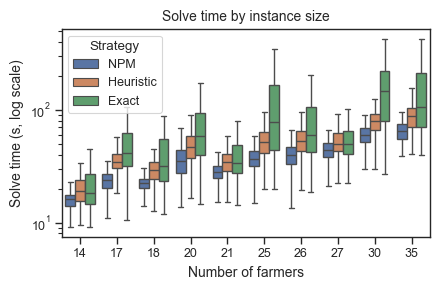

In [18]:
time_df = pd.concat([
    plot_df[["n_farmers", "time"]].assign(Strategy=plot_df["Strategy"]),
    df[["n_farmers", "exact_time"]].rename(columns={"exact_time": "time"}).drop_duplicates().assign(Strategy="Exact"),
])

STRATEGY_ORDER = ["NPM", "Heuristic", "Exact"]

plt.figure(figsize=(4.5, 3))

ax = sns.boxplot(
    data=time_df,
    x="n_farmers",
    y="time",
    hue="Strategy",
    hue_order=STRATEGY_ORDER,
    showfliers=False,
)

ax.set_yscale("log")
ax.set_xlabel("Number of farmers")
ax.set_ylabel("Solve time (s, log scale)")
ax.set_title("Solve time by instance size")

plt.tight_layout()
plt.savefig("../figures/exp_8/solve_time_by_size.png", bbox_inches="tight", dpi=300)
plt.show()


## Reproducing the largest NPM optimality gap

Identify the specific (job_id, run_index) with the largest NPM gap (~122%), then re-run the same instance/parameters locally with the actual `Optimizer` to confirm we can recreate the exact and NPM solutions from scratch.

In [19]:
worst = df.query("strategy == 'npm'").sort_values("rel_gap", ascending=False).iloc[0]
worst


job_id                            146
run_index                           2
instance_file         2020-08-29.yaml
n_farmers                          30
n_intermediaries                   14
strategy                          npm
exact_profit             42772.144627
profit                   -9347.882351
abs_gap                  52120.026978
rel_gap                      1.218551
exact_time                 241.517534
time                        83.970818
total_oracle_calls                  9
internal_rel_gap            23.559849
Name: 2863, dtype: object

In [20]:
# pull the recorded run payload for (job_id, run_index) so we have the exact
# params/profits that were saved, to compare our local re-run against.
worst_job_id = int(worst["job_id"])
worst_run_index = int(worst["run_index"])

worst_file = next(f for f in jsons if f.name == f"job_{worst_job_id}.json.gz")
with gzip.open(worst_file, "rt", encoding="utf-8") as f:
    worst_payload = json.load(f)

worst_run = next(r for r in worst_payload["runs"] if r["metadata"]["run_index"] == worst_run_index)
recorded_exact_profit = worst_run["summary_exact"]["platform_solve_result"]["primary_result"]["platform_profit"]
recorded_npm_profit = worst_run["summary_npm"]["platform_solve_result"]["primary_result"]["platform_profit"]

print(f"job_id={worst_job_id}, run_index={worst_run_index}, instance_file={worst_run['metadata']['instance_file']}")
print(f"recorded exact profit: {recorded_exact_profit}")
print(f"recorded npm profit:   {recorded_npm_profit}")


job_id=146, run_index=2, instance_file=2020-08-29.yaml
recorded exact profit: 42772.144626915455
recorded npm profit:   -9347.882350876927


In [21]:
import sys
import pickle as pkl

sys.path.insert(0, str(Path("../experiments/exp_8").resolve()))
import exp_8  # noqa: E402

from stable_platform_matchings import Optimizer  # noqa: E402
from stable_platform_matchings.optimization.options import OptimizerParams, SolverOptions  # noqa: E402
from stable_platform_matchings.domain.instance import Instance  # noqa: E402
from stable_platform_matchings.graphs.road_graphs import RoadGraph  # noqa: E402

# same instance_paths list exp_8.main() builds, so instance_paths[instance_index]
# lines up with the recorded instance_index/instance_file
data_path = Path("../data")
instances_path = data_path / "anon_14_day_instances"
instance_paths = sorted(
    p for p in instances_path.iterdir()
    if p.is_file() and p.suffix.lower() in {".yaml", ".yml"} and not p.name.startswith("aggregate")
)

with open(data_path / "graph_0-14960_00_new.pickle", "rb") as f:
    graph = pkl.load(f)

print(f"instance_paths[{worst_run['metadata']['instance_index']}] = {instance_paths[worst_run['metadata']['instance_index']].name}")


instance_paths[2] = 2020-08-29.yaml


In [22]:
# Re-run exp_8's own run_one() with the same job_id/run_index. Seeding is
# deterministic (np.random.SeedSequence([BASE_SEED, job_id, run_index])), so this
# should reproduce the identical instance perturbation, epsilons, het_costs, and
# solver seed as the original job run -- letting us sanity check the recorded
# 122% NPM gap end to end rather than trusting the saved JSON alone.
local_result = exp_8.run_one(
    job_id=worst_job_id,
    run_index=worst_run_index,
    instance_paths=instance_paths,
    graph=graph,
    solver_threads=4,
)


Setting random seeding...
Loading instance...
Loaded instance ../data/anon_14_day_instances/2020-08-29.yaml, setting graph...


Sampling inputs...
Initializing optimizer...


============================= Optimizer Parameters =============================
---------------------------------- het_costs -----------------------------------
  {'beautiful_bohr': -18214.30207650375,
   'competent_mayer': 99303.8016015807,
   'elated_haslett': 1028354.38974088,
   'elegant_gagarin': 459061.562021453,
   'elegant_mendel': 63789.497328827405,
   'exciting_fermi': 406941.53504366556,
   'gallant_cerf': 440927.2035237761,
   'hopeful_sanderson': 580907.3469654821,
   'keen_visvesvaraya': 912145.1531619794,
   'laughing_mestorf': 560403.0459223335,
   'loving_engelbart': 821181.1070104316,
   'peaceful_austin': 569256.2168013457,
   'quizzical_elgamal': 631990.4469756951,
   'vigorous_mccarthy': 507700.3849240876}
  backend                    gurobi
  vrp_mode                   approximate
  verbose                    True
  print_width                80
  threads                    4
  vrp_time_limit_seconds     900
  farme

Set parameter LicenseID to value 2717834


--------------------------------------------


--------------------------------------------


...

---------------------------- Lower Bound Candidate -----------------------------
  Objective                  -79,117.879
  Minimum-cost set:
    ['beautiful_bohr',
     'competent_mayer',
     'elegant_gagarin',
     'elegant_mendel',
     'exciting_fermi',
     'gallant_cerf']

............................. Global Bound Update ..............................
  [STATUS] Improved the global lower bound
  Lower bound                -inf -> -79,117.879
  Upper bound                210,886.810 -> 210,886.810
  Absolute gap               inf -> 290,004.689
  Relative gap (%)           undefined -> 366.548%


============================== Branch Evaluation ===============================
  Forced matched:
    ['beautiful_bohr']
  Forced unmatched:
    []

-------------------------- Checking Upper Bound (k=1) --------------------------
  U_1                        210,886.810
---------------------------- Solved pricing for P_1 ----------------------------
  Objective                  -79,117

---------------------------- Lower Bound Candidate -----------------------------
  Objective                  -117,597.052
  Minimum-cost set:
    ['beautiful_bohr',
     'competent_mayer',
     'elegant_mendel',
     'exciting_fermi',
     'gallant_cerf',
     'vigorous_mccarthy']


============================== Branch Evaluation ===============================
  Forced matched:
    ['beautiful_bohr',
     'competent_mayer',
     'elegant_gagarin',
     'elegant_mendel',
     'vigorous_mccarthy']
  Forced unmatched:
    []

-------------------------- Checking Upper Bound (k=5) --------------------------
  U_5                        144,113.629


---------------------------- Lower Bound Candidate -----------------------------
  Objective                  -135,731.411
  Minimum-cost set:
    ['beautiful_bohr',
     'competent_mayer',
     'elegant_gagarin',
     'elegant_mendel',
     'exciting_fermi',
     'vigorous_mccarthy']


============================== Branch Evaluation ===============================
  Forced matched:
    ['beautiful_bohr',
     'competent_mayer',
     'elegant_gagarin',
     'elegant_mendel',
     'laughing_mestorf',
     'vigorous_mccarthy']
  Forced unmatched:
    []

-------------------------- Checking Upper Bound (k=6) --------------------------
  U_6                        -9,347.882


---------------------------- Lower Bound Candidate -----------------------------
  Objective                  -9,347.882
  Minimum-cost set:
    ['beautiful_bohr',
     'competent_mayer',
     'elegant_gagarin',
     'elegant_mendel',
     'laughing_mestorf',
     'vigorous_mccarthy']

............................. Global Bound Update ..............................
  [STATUS] Improved the global lower bound
  Lower bound                -79,117.879 -> -9,347.882
  LB improvement             69,769.996
  Upper bound                210,886.810 -> 210,886.810
  Absolute gap               290,004.689 -> 220,234.692
  Relative gap (%)           366.548% -> 2355.985%


============================== Branch Evaluation ===============================
  Forced matched:
    ['beautiful_bohr',
     'competent_mayer',
     'elegant_gagarin',
     'elegant_mendel',
     'gallant_cerf',
     'laughing_mestorf',
     'vigorous_mccarthy']
  Forced unmatched:
    []

-------------------------- Checking 

----------------------------- Primal Solve Result ------------------------------
  Platform profit            -9,347.882
  Max intermediary welfare   1,732,641.528
  Max farmer welfare         108,204,797.479


=============================== Solver Complete ================================
  Total time (seconds)       17.471
  Oracle calls               9
  Best lower bound           -9,347.882
  Best upper bound           210,886.810
  Absolute gap               220,234.692
  Relative gap (%)           2355.985%


In [23]:
local_exact_profit = local_result["summary_exact"]["platform_solve_result"]["primary_result"]["platform_profit"]
local_npm_profit = local_result["summary_npm"]["platform_solve_result"]["primary_result"]["platform_profit"]

print(f"exact profit  -- recorded: {recorded_exact_profit:.4f}  local: {local_exact_profit:.4f}")
print(f"npm profit    -- recorded: {recorded_npm_profit:.4f}  local: {local_npm_profit:.4f}")

local_rel_gap = (local_exact_profit - local_npm_profit) / abs(local_exact_profit)
print(f"\nrecorded rel_gap: {worst['rel_gap']:.4%}")
print(f"local rel_gap:    {local_rel_gap:.4%}")

assert abs(local_exact_profit - recorded_exact_profit) < 1e-3, "exact profit did not reproduce"
assert abs(local_npm_profit - recorded_npm_profit) < 1e-3, "npm profit did not reproduce"
print("\nReproduced the recorded run exactly.")


exact profit  -- recorded: 42772.1446  local: 42772.1446
npm profit    -- recorded: -9347.8824  local: -9347.8824

recorded rel_gap: 121.8551%
local rel_gap:    121.8551%

Reproduced the recorded run exactly.


## Why did NPM do so badly here? Compare selected intermediaries

In [24]:
exact_primary = local_result["summary_exact"]["platform_solve_result"]["primary_result"]
npm_primary = local_result["summary_npm"]["platform_solve_result"]["primary_result"]

exact_selected = set(exact_primary["selected_intermediaries"])
npm_selected = set(npm_primary["selected_intermediaries"])

print("Exact selected intermediaries:", sorted(exact_selected))
print("NPM selected intermediaries:  ", sorted(npm_selected))
print()
print("In exact but not NPM:", sorted(exact_selected - npm_selected))
print("In NPM but not exact:", sorted(npm_selected - exact_selected))
print("In both:             ", sorted(exact_selected & npm_selected))
print()
print(f"exact platform profit: {exact_primary['platform_profit']:.2f}")
print(f"npm platform profit:   {npm_primary['platform_profit']:.2f}")
print(f"exact expected intermediary cost: {exact_primary['expected_intermediary_cost']:.2f}")
print(f"npm expected intermediary cost:   {npm_primary['expected_intermediary_cost']:.2f}")


Exact selected intermediaries: ['beautiful_bohr', 'competent_mayer', 'elegant_mendel', 'exciting_fermi', 'laughing_mestorf', 'vigorous_mccarthy']
NPM selected intermediaries:   ['beautiful_bohr', 'competent_mayer', 'elegant_gagarin', 'elegant_mendel', 'laughing_mestorf', 'vigorous_mccarthy']

In exact but not NPM: ['exciting_fermi']
In NPM but not exact: ['elegant_gagarin']
In both:              ['beautiful_bohr', 'competent_mayer', 'elegant_mendel', 'laughing_mestorf', 'vigorous_mccarthy']

exact platform profit: 42772.14
npm platform profit:   -9347.88
exact expected intermediary cost: 8855627.08
npm expected intermediary cost:   8907747.11


In [25]:
params = local_result["summary_exact"]["params"]
het_costs = params["het_costs"]
epsilons = params["epsilons"]

# status-quo quantity per intermediary, matching HIST_SET_METHOD = "instance_farmers"
farmer_quantity_by_intermediary = {}
for farmer in local_result["summary_exact"]["instance_snapshot"]["farmers"]:
    farmer_quantity_by_intermediary[farmer["intermediary_id"]] = (
        farmer_quantity_by_intermediary.get(farmer["intermediary_id"], 0.0) + farmer["quantity"]
    )

K = local_result["summary_exact"]["instance_snapshot"]["constants"]["truck_capacity_tons"]

compare_rows = []
for intermediary_id in het_costs:
    n = farmer_quantity_by_intermediary.get(intermediary_id, 0.0)
    eps = epsilons[intermediary_id]
    sigma = het_costs[intermediary_id]
    network_priority = sigma / min(K, max(n + eps, 1e-4))
    compare_rows.append({
        "intermediary_id": intermediary_id,
        "het_cost": sigma,
        "status_quo_quantity": n,
        "epsilon": eps,
        "network_priority": network_priority,
        "in_exact": intermediary_id in exact_selected,
        "in_npm": intermediary_id in npm_selected,
    })

compare_df = pd.DataFrame(compare_rows).sort_values("network_priority")
compare_df


,intermediary_id,het_cost,status_quo_quantity,epsilon,network_priority,in_exact,in_npm
2,beautiful_bohr,-1.821430e+04,8.2,3.281290,-2.023811e+03,True,True
3,elegant_mendel,6.378950e+04,4.3,3.172601,8.536452e+03,True,True
1,competent_mayer,9.930380e+04,2.5,2.503141,1.984829e+04,True,True
6,vigorous_mccarthy,5.077004e+05,5.6,5.022976,5.641115e+04,True,True
4,elegant_gagarin,4.590616e+05,3.6,3.833771,6.175352e+04,False,True
9,laughing_mestorf,5.604030e+05,9.3,5.362087,6.226701e+04,True,True
7,gallant_cerf,4.409272e+05,1.6,4.279468,7.499441e+04,False,False
10,peaceful_austin,5.692562e+05,3.0,4.417922,7.674066e+04,False,False
12,loving_engelbart,8.211811e+05,7.2,4.827883,9.124235e+04,False,False
8,elated_haslett,1.028354e+06,1.8,0.506610,4.458293e+05,False,False


**Diagnosis**: both solutions pick 6 of the same intermediaries; they differ on exactly one swap: exact keeps `exciting_fermi`, NPM keeps `elegant_gagarin` instead.

Looking at the `network_priority = het_cost / min(K, status_quo_quantity + epsilon)` table above, `elegant_gagarin` has a *higher* het_cost (459,062) than `exciting_fermi` (406,942) -- `exciting_fermi` is the objectively cheaper intermediary to add. But `exciting_fermi` has **zero status-quo quantity** (`n=0`) in this instance, so its priority score gets divided by just `epsilon=0.585` (`406,942 / 0.585 ≈ 695,125`), while `elegant_gagarin`'s `n+epsilon=7.43` keeps its score much lower (`≈ 61,754`) despite its higher raw cost.

NPM's greedy priority ordering is exactly `het_cost / min(K, n+epsilon)`, so it ranks `exciting_fermi` as *worse* than `elegant_gagarin` purely because of this normalization -- an intermediary with no historical farmers looks artificially "expensive per unit of reliable capacity" even when its actual fixed cost is lower. NPM never backtracks to reconsider a cheaper-but-zero-history intermediary once a costlier-but-established one has been greedily included ahead of it in priority order, so it locks in the wrong 6th member and the resulting matching/payment structure ends up not just suboptimal but profit-losing (-9,347.88 vs. +42,772.14).

## Two more large-gap cases

Repeat the same diagnosis (reproduce locally, compare selected intermediaries, inspect the network-priority table) for the 2nd- and 3rd-worst NPM runs (from distinct instances/jobs, to avoid picking two runs of the same underlying instance): `job_157/run_3` (gap 114.6%) and `job_24/run_9` (gap 54.3%).

In [26]:
def diagnose_npm_case(job_id: int, run_index: int):
    """Reproduce a specific exp_8 run and diagnose why NPM's selected set differs from exact's."""
    file = next(f for f in jsons if f.name == f"job_{job_id}.json.gz")
    with gzip.open(file, "rt", encoding="utf-8") as f:
        payload = json.load(f)
    run = next(r for r in payload["runs"] if r["metadata"]["run_index"] == run_index)

    recorded_exact = run["summary_exact"]["platform_solve_result"]["primary_result"]["platform_profit"]
    recorded_npm = run["summary_npm"]["platform_solve_result"]["primary_result"]["platform_profit"]
    print(f"job_id={job_id}, run_index={run_index}, instance_file={run['metadata']['instance_file']}")
    print(f"recorded exact profit: {recorded_exact:.2f}    recorded npm profit: {recorded_npm:.2f}")

    result = exp_8.run_one(
        job_id=job_id,
        run_index=run_index,
        instance_paths=instance_paths,
        graph=graph,
        solver_threads=4,
    )

    exact_primary = result["summary_exact"]["platform_solve_result"]["primary_result"]
    npm_primary = result["summary_npm"]["platform_solve_result"]["primary_result"]

    local_exact = exact_primary["platform_profit"]
    local_npm = npm_primary["platform_profit"]
    local_rel_gap = (local_exact - local_npm) / abs(local_exact)
    print(f"local exact profit:    {local_exact:.2f}    local npm profit:    {local_npm:.2f}")
    print(f"local relative gap: {local_rel_gap:.2%}")
    print(f"exact expected_intermediary_cost: {exact_primary['expected_intermediary_cost']:.2f}")
    print(f"npm expected_intermediary_cost:   {npm_primary['expected_intermediary_cost']:.2f}")

    exact_selected = set(exact_primary["selected_intermediaries"])
    npm_selected = set(npm_primary["selected_intermediaries"])
    print()
    only_exact = sorted(exact_selected - npm_selected)
    only_npm = sorted(npm_selected - exact_selected)
    print("In exact but not NPM:", only_exact)
    print("In NPM but not exact:", only_npm)

    dist_to_mill = result["summary_exact"]["instance_snapshot"]["distances"]["total"]
    for iid in only_exact + only_npm:
        print(f"  {iid}: dist_to_mill={dist_to_mill.get(iid):.0f}")

    params = result["summary_exact"]["params"]
    het_costs = params["het_costs"]
    epsilons = params["epsilons"]
    K = result["summary_exact"]["instance_snapshot"]["constants"]["truck_capacity_tons"]

    farmer_quantity_by_intermediary = {}
    for farmer in result["summary_exact"]["instance_snapshot"]["farmers"]:
        farmer_quantity_by_intermediary[farmer["intermediary_id"]] = (
            farmer_quantity_by_intermediary.get(farmer["intermediary_id"], 0.0) + farmer["quantity"]
        )

    compare_rows = []
    for intermediary_id in het_costs:
        n = farmer_quantity_by_intermediary.get(intermediary_id, 0.0)
        eps = epsilons[intermediary_id]
        sigma = het_costs[intermediary_id]
        network_priority = sigma / min(K, max(n + eps, 1e-4))
        compare_rows.append({
            "intermediary_id": intermediary_id,
            "het_cost": sigma,
            "status_quo_quantity": n,
            "epsilon": eps,
            "network_priority": network_priority,
            "in_exact": intermediary_id in exact_selected,
            "in_npm": intermediary_id in npm_selected,
        })

    compare_df_local = pd.DataFrame(compare_rows).sort_values("network_priority").reset_index(drop=True)
    return result, compare_df_local


### Case 2: job_157, run_3 (gap 114.6%)

In [27]:
result_157, compare_157 = diagnose_npm_case(job_id=157, run_index=3)
compare_157


job_id=157, run_index=3, instance_file=2020-08-29.yaml
recorded exact profit: 159975.00    recorded npm profit: -23325.28
Setting random seeding...
Loading instance...
Loaded instance ../data/anon_14_day_instances/2020-08-29.yaml, setting graph...


Sampling inputs...
Initializing optimizer...


============================= Optimizer Parameters =============================
---------------------------------- het_costs -----------------------------------
  {'beautiful_bohr': 121177.2416557982,
   'competent_mayer': 423348.85920056084,
   'elated_haslett': 1055025.5883739672,
   'elegant_gagarin': 329633.4067809957,
   'elegant_mendel': 227543.71520887496,
   'exciting_fermi': 525278.9369395527,
   'gallant_cerf': 345253.85306857305,
   'hopeful_sanderson': 711425.2162825075,
   'keen_visvesvaraya': 1163565.8919458217,
   'laughing_mestorf': 600778.0212393561,
   'loving_engelbart': 998019.5360759024,
   'peaceful_austin': 923675.7913360356,
   'quizzical_elgamal': 609466.0099431374,
   'vigorous_mccarthy': 357683.43794699275}
  backend                    gurobi
  vrp_mode                   approximate
  verbose                    True
  print_width                80
  threads                    4
  vrp_time_limit_seconds     900
 

Set parameter TimeLimit to value 900


Gurobi Optimizer version 12.0.3 build v12.0.3rc0 (mac64[arm] - Darwin 25.3.0 25D2128)


CPU model: Apple M4 Pro


...

----------------------------- Primal Solve Result ------------------------------
  Platform profit            159,974.996
  Max intermediary welfare   2,420,981.778
  Max farmer welfare         105,775,372.469


=============================== Solver Complete ================================
  Total time (seconds)       16.923
  Oracle calls               3
  Best lower bound           159,974.996
  Best upper bound           337,404.158
  Absolute gap               177,429.162
  Relative gap (%)           110.911%
Solving with network-prioritized matching...


================================ Solver Options ================================
  Seed                       333096276
  Strategy                   network_prioritized_capped
  Structured Farmer Payments False
  Dominance Constraints      False
  Early Stop Threshold       0.000
  Hist Set Method            instance_farmers
  Pay Unmatched              False
  Stabilize Final Solution   True
----------------------------------- 

-------------------------- Checking Upper Bound (k=0) --------------------------
  U_0                        337,404.158


---------------------------- Lower Bound Candidate -----------------------------
  Objective                  -23,325.282
  Minimum-cost set:
    ['beautiful_bohr',
     'competent_mayer',
     'elegant_gagarin',
     'elegant_mendel',
     'gallant_cerf',
     'vigorous_mccarthy']

............................. Global Bound Update ..............................
  [STATUS] Improved the global lower bound
  Lower bound                -inf -> -23,325.282
  Upper bound                337,404.158 -> 337,404.158
  Absolute gap               inf -> 360,729.441
  Relative gap (%)           undefined -> 1546.517%


============================== Branch Evaluation ===============================
  Forced matched:
    ['beautiful_bohr']
  Forced unmatched:
    []

-------------------------- Checking Upper Bound (k=1) --------------------------
  U_1                        337,404.158
---------------------------- Solved pricing for P_1 ----------------------------
  Objective                  -23

----------------------------- Primal Solve Result ------------------------------
  Platform profit            -23,325.282
  Max intermediary welfare   612,151.999
  Max farmer welfare         107,117,335.698


=============================== Solver Complete ================================
  Total time (seconds)       12.616
  Oracle calls               9
  Best lower bound           -23,325.282
  Best upper bound           337,404.158
  Absolute gap               360,729.441
  Relative gap (%)           1546.517%
local exact profit:    159975.00    local npm profit:    -23325.28
local relative gap: 114.58%
exact expected_intermediary_cost: 9187814.39
npm expected_intermediary_cost:   9010385.23

In exact but not NPM: ['laughing_mestorf']
In NPM but not exact: ['competent_mayer']
  laughing_mestorf: dist_to_mill=160508
  competent_mayer: dist_to_mill=57810


,intermediary_id,het_cost,status_quo_quantity,epsilon,network_priority,in_exact,in_npm
0,beautiful_bohr,1.211772e+05,8.1,3.372248,13464.137962,True,True
1,elegant_gagarin,3.296334e+05,3.7,4.134288,42075.732738,True,True
2,elegant_mendel,2.275437e+05,4.6,0.606516,43703.639423,True,True
3,vigorous_mccarthy,3.576834e+05,4.8,3.127311,45120.397547,True,True
4,competent_mayer,4.233489e+05,2.9,4.555349,56784.581251,False,True
5,gallant_cerf,3.452539e+05,1.7,3.685830,64104.113870,True,True
6,laughing_mestorf,6.007780e+05,8.9,5.373203,66753.113471,True,False
7,exciting_fermi,5.252789e+05,0.0,4.898283,107237.369645,False,False
8,loving_engelbart,9.980195e+05,6.5,1.426483,125909.499474,False,False
9,elated_haslett,1.055026e+06,2.2,3.235398,194102.738411,False,False


**A different mechanism this time.** The swap here is `laughing_mestorf` (exact only) vs. `competent_mayer` (NPM only) -- and both have substantial nonzero status-quo quantity (8.9 and 2.9 tons respectively), so this is *not* the zero-history artifact from before. In fact NPM's own priority index ranks `competent_mayer` (score ≈56.8k) as better than `laughing_mestorf` (score ≈66.8k), and `laughing_mestorf` also has more than 5x `competent_mayer`'s distance to the mill (160.5km vs 57.8km) -- so on both the priority index and pure geography, `competent_mayer` looks like the better pick. Yet the true optimum keeps `laughing_mestorf` and drops `competent_mayer`, and does so while paying a *higher* total intermediary/routing cost (9.19M vs. NPM's 9.01M) for a vastly higher profit (160k vs -23k).

That combination -- worse routing cost, but far better profit -- means the difference isn't about transportation efficiency at all. `laughing_mestorf` has by far the largest status-quo quantity in the instance (8.9 tons, close to a full truck), making it a genuinely large stability threat: leaving it unmatched would require expensive payments elsewhere to keep it from deviating. NPM's index treats "cost per unit of capped deviation potential" as a self-contained per-intermediary score and picks the top-k by that score alone; it has no way to see that matching a large, real threat can be worth a strictly higher own fixed/routing cost once you account for what unmatched intermediaries force the platform to pay everyone else to keep stable. This is a second, independent failure mode from the zero-history one -- the index can misorder two intermediaries that both have perfectly ordinary, nonzero histories.

### Case 3: job_24, run_9 (gap 54.3%)

In [28]:
result_24, compare_24 = diagnose_npm_case(job_id=24, run_index=9)
compare_24


job_id=24, run_index=9, instance_file=2020-09-04.yaml
recorded exact profit: 16172.49    recorded npm profit: 7389.84
Setting random seeding...
Loading instance...
Loaded instance ../data/anon_14_day_instances/2020-09-04.yaml, setting graph...


Sampling inputs...
Initializing optimizer...


============================= Optimizer Parameters =============================
---------------------------------- het_costs -----------------------------------
  {'beautiful_bohr': 361984.8094178131,
   'competent_mayer': 239503.38336868075,
   'elated_haslett': 811880.7592772582,
   'elegant_gagarin': 449899.9569113583,
   'elegant_mendel': 296718.16383312014,
   'exciting_fermi': 287935.50609167427,
   'gallant_cerf': 351288.6503383537,
   'hopeful_sanderson': 521375.5259260948,
   'keen_visvesvaraya': 1168478.9643755485,
   'laughing_mestorf': 536663.0477321551,
   'loving_engelbart': 906799.0764434526,
   'peaceful_austin': 702200.5599352648,
   'quizzical_elgamal': 791488.4913458658,
   'vigorous_mccarthy': 252680.51189350727}
  backend                    gurobi
  vrp_mode                   approximate
  verbose                    True
  print_width                80
  threads                    4
  vrp_time_limit_seconds     900
  

Set parameter TimeLimit to value 900


Gurobi Optimizer version 12.0.3 build v12.0.3rc0 (mac64[arm] - Darwin 25.3.0 25D2128)


CPU model: Apple M4 Pro


...

-------------------------- Checking Upper Bound (k=0) --------------------------
  U_0                        240,829.855


---------------------------- Lower Bound Candidate -----------------------------
  Objective                  -80,488.212
  Minimum-cost set:
    ['competent_mayer', 'elegant_mendel', 'exciting_fermi', 'vigorous_mccarthy']

............................. Global Bound Update ..............................
  [STATUS] Improved the global lower bound
  Lower bound                -inf -> -80,488.212
  Upper bound                240,829.855 -> 240,829.855
  Absolute gap               inf -> 321,318.066
  Relative gap (%)           undefined -> 399.211%


============================== Branch Evaluation ===============================
  Forced matched:
    ['vigorous_mccarthy']
  Forced unmatched:
    []

-------------------------- Checking Upper Bound (k=1) --------------------------
  U_1                        240,829.855
---------------------------- Solved pricing for P_1 ----------------------------
  Objective                  -80,488.212
  Minimum-cost set:
    ['competent_mayer', 'eleg

---------------------------- Lower Bound Candidate -----------------------------
  Objective                  7,389.835
  Minimum-cost set:
    ['competent_mayer',
     'elegant_mendel',
     'hopeful_sanderson',
     'vigorous_mccarthy']

............................. Global Bound Update ..............................
  [STATUS] Improved the global lower bound
  Lower bound                -80,488.212 -> 7,389.835
  LB improvement             87,878.047
  Upper bound                240,829.855 -> 240,829.855
  Absolute gap               321,318.066 -> 233,440.020
  Relative gap (%)           399.211% -> 3158.934%


============================== Branch Evaluation ===============================
  Forced matched:
    ['competent_mayer',
     'elegant_mendel',
     'hopeful_sanderson',
     'laughing_mestorf',
     'vigorous_mccarthy']
  Forced unmatched:
    []

-------------------------- Checking Upper Bound (k=5) --------------------------
  U_5                        -1,329,273.213
 

----------------------------- Primal Solve Result ------------------------------
  Platform profit            7,389.835
  Max intermediary welfare   820,238.891
  Max farmer welfare         61,394,623.351


=============================== Solver Complete ================================
  Total time (seconds)       5.243
  Oracle calls               7
  Best lower bound           7,389.835
  Best upper bound           240,829.855
  Absolute gap               233,440.020
  Relative gap (%)           3158.934%
local exact profit:    16172.49    local npm profit:    7389.84
local relative gap: 54.31%
exact expected_intermediary_cost: 6364786.10
npm expected_intermediary_cost:   6373568.76

In exact but not NPM: ['exciting_fermi']
In NPM but not exact: ['elegant_mendel']
  exciting_fermi: dist_to_mill=73144
  elegant_mendel: dist_to_mill=37000


,intermediary_id,het_cost,status_quo_quantity,epsilon,network_priority,in_exact,in_npm
0,vigorous_mccarthy,2.526805e+05,1.7,5.379371,35692.510834,True,True
1,competent_mayer,2.395034e+05,1.9,2.867813,50233.389285,True,True
2,elegant_mendel,2.967182e+05,4.2,1.135158,55615.624984,False,True
3,hopeful_sanderson,5.213755e+05,8.7,3.845739,57930.613992,True,True
4,laughing_mestorf,5.366630e+05,1.8,5.481611,73701.140925,False,False
5,exciting_fermi,2.879355e+05,0.0,3.825323,75270.894190,True,False
6,elegant_gagarin,4.499000e+05,0.0,4.124573,109077.956825,False,False
7,loving_engelbart,9.067991e+05,3.8,2.349175,147466.784455,False,False
8,elated_haslett,8.118808e+05,5.1,0.370193,148419.034324,False,False
9,beautiful_bohr,3.619848e+05,0.0,2.074995,174450.970444,False,False


**Back to the zero-history mechanism.** Here the swap is `exciting_fermi` (exact only, `n=0`) vs. `elegant_mendel` (NPM only, `n=4.2`) -- the same intermediary, `exciting_fermi`, that caused the very first case, again dropped by NPM despite being (marginally) the cheaper of the two on raw `het_cost` (287,935 vs. 296,718). Its zero status-quo quantity again inflates its priority score well past `elegant_mendel`'s (75,271 vs. 55,616), for the identical reason as before: dividing by `epsilon` alone when `n=0` overstates how "expensive per unit of relevance" a cheap-but-unproven intermediary looks.

So across three worst-case instances: two (this one and the original) are the zero-history pathology, and one (`job_157`) is a distinct failure where NPM's index misorders two intermediaries that both have ordinary nonzero histories, because the index has no visibility into the platform-wide stability payments that a large, genuine deviation threat can save by being matched. Both mechanisms point at the same root limitation: the index is a purely local, per-intermediary score, while the actual objective (profit net of routing cost *and* stability payments across the whole matched set) is inherently combinatorial.

## Testing a variant index on case 2 (job_157): drop the capacity cap

Case 2's swap wasn't the zero-history pathology -- both `laughing_mestorf` (n=8.9) and `competent_mayer` (n=2.9) have ordinary nonzero histories, yet NPM still picked the wrong one. `laughing_mestorf`'s `n+epsilon = 14.27` exceeds `K=9`, so the current index's `min(K, n+eps)` cap flattens its denominator at 9, giving it a *worse* (higher) priority score (66.8k) than `competent_mayer`'s (56.8k) even though `laughing_mestorf` is the one the true optimum needs matched for stability.

If we instead divide by the *uncapped* `n+epsilon`, `laughing_mestorf`'s score becomes `600,778 / 14.27 ≈ 42,090` -- lower than `competent_mayer`'s 56.8k -- which would flip the greedy ordering and might let NPM pick the right 6th member here. Let's actually run this variant rather than just eyeballing the arithmetic: copy `solve_npm` into the notebook with only that one line changed, monkey-patch it into the `Optimizer` dispatch, and re-solve job_157/run_3.

In [29]:
from stable_platform_matchings.optimization.branch import Branch
from stable_platform_matchings.optimization.solvers.search_strategies import print_bound_update


def solve_npm_uncapped(optimizer, capped=None) -> None:
    # 'capped' kwarg accepted (and ignored) for compatibility with the current
    # Optimizer.solve() dispatch, which now always passes capped=True/False;
    # this function only ever implements the uncapped variant regardless.
    """Copy of solve_npm (search_strategies.py:7-134) with ONE change: the priority
    index divides by (n_t + eps_t) directly, without the min(K, ...) capacity cap."""

    def compute_network_priority(intermediary):
        """NPM_uncapped(t) := sigma_t / (n_t + eps_t)  -- no capacity cap"""
        het_costs = optimizer.het_costs
        sigma = het_costs[intermediary.id]
        n = optimizer.status_quo_quantities[intermediary.id]
        eps = optimizer.epsilons[intermediary.id]
        return sigma / max(n + eps, float(1e-4))

    network_priorities = [
        (intermediary.id, compute_network_priority(intermediary))
        for intermediary in optimizer.instance.intermediaries
    ]
    optimizer.output.section("Network Priority Order (uncapped variant)")
    optimizer.output.collection(
        label="Network Priorities (sorted)",
        values=sorted(network_priorities, key=lambda x: x[1])
    )
    network_priority_order = [item[0] for item in sorted(network_priorities, key=lambda x: x[1])]

    P = set()
    pricing_cache = {}
    U_0, C_0 = float("inf"), float("inf")
    for k in range(len(network_priority_order) + 1):
        if k > 0:
            P = P.union({network_priority_order[k - 1]})

        branch = Branch(forced_match=P, forced_unmatch=set())
        if not optimizer.initialize_branch(branch):
            break

        if k == 0:
            forced_ub_result = optimizer.solve_primal_for_branch(
                branch=branch,
                sol_type="forced_upper_bound",
                compute_intermediary_welfare=False,
                compute_farmer_welfare=False
            )
            U_0 = forced_ub_result.platform_profit
            C_0 = branch.min_cost

            optimizer.instance_summary.forced_upper_bound = U_0
            optimizer.best_ub = U_0

        U_k = U_0 - (branch.min_cost - C_0)

        optimizer.output.subsection(f"Checking Upper Bound (k={k})")
        optimizer.output.metric(f"U_{k}", U_k)
        if not optimizer.exceeds_global_lb(U_k, optimizer.BRANCH_PRUNE_TOL):
            optimizer.output.status(
                "U_k cannot improve on the incumbent; stopping network-prioritized search."
            )
            break

        if branch.min_cost_set in pricing_cache:
            optimizer.output.subsection(f"Solved pricing for P_{k}")
            optimizer.output.metric("Objective", pricing_cache[branch.min_cost_set])
            optimizer.output.collection("Minimum-cost set", sorted(branch.min_cost_set))
            continue

        forced_lb_result = optimizer.solve_primal_for_branch(
            branch=branch,
            sol_type="forced_lower_bound",
            compute_intermediary_welfare=False,
            compute_farmer_welfare=False,
        )
        branch_profit = forced_lb_result.platform_profit
        pricing_cache[branch.min_cost_set] = branch_profit

        if k == 0:
            optimizer.instance_summary.forced_lower_bound = branch_profit

        optimizer.output.subsection("Lower Bound Candidate")
        optimizer.output.metric("Objective", forced_lb_result.platform_profit)
        optimizer.output.collection("Minimum-cost set", sorted(branch.min_cost_set))

        if optimizer.exceeds_global_lb(
            forced_lb_result.platform_profit, optimizer.GLOBAL_LB_UPDATE_TOL
        ):
            previous_lb = optimizer.best_lb
            previous_ub = optimizer.best_ub

            optimizer.best_lb = forced_lb_result.platform_profit
            optimizer.best_lb_set = branch.min_cost_set
            optimizer.best_lb_result = forced_lb_result

            optimizer.record_summary()

            print_bound_update(
                optimizer,
                title="Global Bound Update",
                status="Improved the global lower bound",
                previous_lb=previous_lb,
                previous_ub=previous_ub,
                fill=".",
            )

    previous_lb = optimizer.best_lb
    previous_ub = optimizer.best_ub

    optimizer.record_summary()

    print_bound_update(
        optimizer,
        title="Search Complete",
        status="",
        previous_lb=previous_lb,
        previous_ub=previous_ub,
        fill="=",
    )


In [30]:
import stable_platform_matchings.optimization.optimizer as optimizer_module

original_solve_npm = optimizer_module.solve_npm
optimizer_module.solve_npm = solve_npm_uncapped
try:
    result_157_uncapped = exp_8.run_one(
        job_id=157,
        run_index=3,
        instance_paths=instance_paths,
        graph=graph,
        solver_threads=4,
    )
finally:
    optimizer_module.solve_npm = original_solve_npm

npm_uncapped_primary = result_157_uncapped["summary_npm"]["platform_solve_result"]["primary_result"]
exact_primary_157 = result_157_uncapped["summary_exact"]["platform_solve_result"]["primary_result"]
npm_capped_primary_157 = result_157["summary_npm"]["platform_solve_result"]["primary_result"]

exact_selected_157 = set(exact_primary_157["selected_intermediaries"])
npm_uncapped_selected = set(npm_uncapped_primary["selected_intermediaries"])

uncapped_profit = npm_uncapped_primary["platform_profit"]
exact_profit_157 = exact_primary_157["platform_profit"]
uncapped_rel_gap = (exact_profit_157 - uncapped_profit) / abs(exact_profit_157)

print(f"exact profit:            {exact_profit_157:.2f}")
print(f"npm (capped) profit:     {npm_capped_primary_157['platform_profit']:.2f}")
print(f"npm (uncapped) profit:   {uncapped_profit:.2f}")
print(f"npm (uncapped) rel_gap:  {uncapped_rel_gap:.2%}")
print()
print("NPM (uncapped) selected:", sorted(npm_uncapped_selected))
print("Exact selected:         ", sorted(exact_selected_157))
print("Still differs by:", sorted(exact_selected_157 ^ npm_uncapped_selected))


Setting random seeding...
Loading instance...
Loaded instance ../data/anon_14_day_instances/2020-08-29.yaml, setting graph...


Sampling inputs...
Initializing optimizer...


============================= Optimizer Parameters =============================
---------------------------------- het_costs -----------------------------------
  {'beautiful_bohr': 121177.2416557982,
   'competent_mayer': 423348.85920056084,
   'elated_haslett': 1055025.5883739672,
   'elegant_gagarin': 329633.4067809957,
   'elegant_mendel': 227543.71520887496,
   'exciting_fermi': 525278.9369395527,
   'gallant_cerf': 345253.85306857305,
   'hopeful_sanderson': 711425.2162825075,
   'keen_visvesvaraya': 1163565.8919458217,
   'laughing_mestorf': 600778.0212393561,
   'loving_engelbart': 998019.5360759024,
   'peaceful_austin': 923675.7913360356,
   'quizzical_elgamal': 609466.0099431374,
   'vigorous_mccarthy': 357683.43794699275}
  backend                    gurobi
  vrp_mode                   approximate
  verbose                    True
  print_width                80
  threads                    4
  vrp_time_limit_seconds     900
 

Set parameter TimeLimit to value 900


Gurobi Optimizer version 12.0.3 build v12.0.3rc0 (mac64[arm] - Darwin 25.3.0 25D2128)


CPU model: Apple M4 Pro


...

----------------------------- Primal Solve Result ------------------------------
  Platform profit            159,974.996
  Max intermediary welfare   2,420,981.778
  Max farmer welfare         105,775,372.469


=============================== Solver Complete ================================
  Total time (seconds)       16.959
  Oracle calls               3
  Best lower bound           159,974.996
  Best upper bound           337,404.158
  Absolute gap               177,429.162
  Relative gap (%)           110.911%
Solving with network-prioritized matching...


================================ Solver Options ================================
  Seed                       333096276
  Strategy                   network_prioritized_capped
  Structured Farmer Payments False
  Dominance Constraints      False
  Early Stop Threshold       0.000
  Hist Set Method            instance_farmers
  Pay Unmatched              False
  Stabilize Final Solution   True
----------------------------------- 

-------------------------- Checking Upper Bound (k=0) --------------------------
  U_0                        337,404.158


---------------------------- Lower Bound Candidate -----------------------------
  Objective                  -23,325.282
  Minimum-cost set:
    ['beautiful_bohr',
     'competent_mayer',
     'elegant_gagarin',
     'elegant_mendel',
     'gallant_cerf',
     'vigorous_mccarthy']

............................. Global Bound Update ..............................
  [STATUS] Improved the global lower bound
  Lower bound                -inf -> -23,325.282
  Upper bound                337,404.158 -> 337,404.158
  Absolute gap               inf -> 360,729.441
  Relative gap (%)           undefined -> 1546.517%


============================== Branch Evaluation ===============================
  Forced matched:
    ['beautiful_bohr']
  Forced unmatched:
    []

-------------------------- Checking Upper Bound (k=1) --------------------------
  U_1                        337,404.158
---------------------------- Solved pricing for P_1 ----------------------------
  Objective                  -23

---------------------------- Lower Bound Candidate -----------------------------
  Objective                  159,974.996
  Minimum-cost set:
    ['beautiful_bohr',
     'elegant_gagarin',
     'elegant_mendel',
     'gallant_cerf',
     'laughing_mestorf',
     'vigorous_mccarthy']

............................. Global Bound Update ..............................
  [STATUS] Improved the global lower bound
  Lower bound                -23,325.282 -> 159,974.996
  LB improvement             183,300.279
  Upper bound                337,404.158 -> 337,404.158
  Absolute gap               360,729.441 -> 177,429.162
  Relative gap (%)           1546.517% -> 110.911%


============================== Branch Evaluation ===============================
  Forced matched:
    ['beautiful_bohr', 'elegant_gagarin', 'elegant_mendel', 'laughing_mestorf']
  Forced unmatched:
    []

-------------------------- Checking Upper Bound (k=4) --------------------------
  U_4                        159,974.996


----------------------------- Primal Solve Result ------------------------------
  Platform profit            159,974.996
  Max intermediary welfare   2,420,981.778
  Max farmer welfare         105,775,372.469


=============================== Solver Complete ================================
  Total time (seconds)       12.617
  Oracle calls               6
  Best lower bound           159,974.996
  Best upper bound           337,404.158
  Absolute gap               177,429.162
  Relative gap (%)           110.911%
exact profit:            159975.00
npm (capped) profit:     -23325.28
npm (uncapped) profit:   159975.00
npm (uncapped) rel_gap:  0.00%

NPM (uncapped) selected: ['beautiful_bohr', 'elegant_gagarin', 'elegant_mendel', 'gallant_cerf', 'laughing_mestorf', 'vigorous_mccarthy']
Exact selected:          ['beautiful_bohr', 'elegant_gagarin', 'elegant_mendel', 'gallant_cerf', 'laughing_mestorf', 'vigorous_mccarthy']
Still differs by: []


**It worked, exactly as predicted.** Dropping the capacity cap flips `laughing_mestorf` and `competent_mayer` into the correct relative order, and NPM's selected set becomes identical to exact's -- profit goes from -23,325 (114.6% gap) to 159,975 (**0% gap**), matching the true optimum exactly.

Two caveats worth flagging before reading too much into this:
- This confirms the *mechanism* for this specific instance, not that removing the cap is a safe general fix. The cap `min(K, n+eps)` exists for a reason -- it's meant to reflect that no intermediary can plausibly deviate with more than a truckload (`K` tons), so uncapping it will overstate deviation potential for any intermediary whose `n+eps` exceeds `K` for a *different* reason. It's entirely possible this fix helps here but hurts on other instances where the cap was doing legitimate work (e.g. distinguishing a truly enormous, implausible `n+eps` from a merely large one).
- We should check whether this uncapped variant still reproduces `Π^eff` correctly at `k=0` and preserves Corollary 2's guarantee in the stylized two-type setting, since the cap is part of the index the paper actually proves exactness for -- removing it changes which heuristic the exactness argument applies to.

The natural next step is exactly experiment #2 from the earlier list: run this variant across the full `exp_8` sweep (not just one instance) and see whether the 27.7% hard-instance failure rate drops, holds steady, or gets worse elsewhere.

## Does the uncapped variant also fix cases 1 and 3?

Cases 1 (`job_146/run_2`) and 3 (`job_24/run_9`) were diagnosed as the *zero-history* mechanism, not the capacity-cap mechanism: in both, the swapped-out intermediary (`exciting_fermi`, `n=0`) has `n+epsilon` well under `K=9` (0.585 and 3.825 respectively), so `min(K, n+eps)` never actually binds -- the cap is a no-op there. If that diagnosis is right, the uncapped variant should produce the *exact same* (wrong) priority scores and the *exact same* selection on these two, since uncapping only changes anything when `n+eps > K`. Let's check rather than assume.

In [31]:
def run_npm_uncapped(job_id: int, run_index: int):
    """Re-solve a given exp_8 run with the uncapped NPM priority index."""
    original = optimizer_module.solve_npm
    optimizer_module.solve_npm = solve_npm_uncapped
    try:
        result = exp_8.run_one(
            job_id=job_id,
            run_index=run_index,
            instance_paths=instance_paths,
            graph=graph,
            solver_threads=4,
        )
    finally:
        optimizer_module.solve_npm = original
    return result


def compare_capped_vs_uncapped(capped_result, uncapped_result, label: str):
    exact_primary = capped_result["summary_exact"]["platform_solve_result"]["primary_result"]
    capped_primary = capped_result["summary_npm"]["platform_solve_result"]["primary_result"]
    uncapped_primary = uncapped_result["summary_npm"]["platform_solve_result"]["primary_result"]

    exact_profit = exact_primary["platform_profit"]
    capped_profit = capped_primary["platform_profit"]
    uncapped_profit = uncapped_primary["platform_profit"]

    capped_gap = (exact_profit - capped_profit) / abs(exact_profit)
    uncapped_gap = (exact_profit - uncapped_profit) / abs(exact_profit)

    exact_selected = set(exact_primary["selected_intermediaries"])
    capped_selected = set(capped_primary["selected_intermediaries"])
    uncapped_selected = set(uncapped_primary["selected_intermediaries"])

    print(f"--- {label} ---")
    print(f"exact profit:          {exact_profit:.2f}")
    print(f"npm (capped) profit:   {capped_profit:.2f}   (gap {capped_gap:.2%})")
    print(f"npm (uncapped) profit: {uncapped_profit:.2f}   (gap {uncapped_gap:.2%})")
    print(f"capped selection == uncapped selection: {capped_selected == uncapped_selected}")
    print(f"uncapped selection == exact selection:  {uncapped_selected == exact_selected}")
    print()


result_146_uncapped = run_npm_uncapped(job_id=146, run_index=2)
compare_capped_vs_uncapped(local_result, result_146_uncapped, "Case 1: job_146/run_2")

result_24_uncapped = run_npm_uncapped(job_id=24, run_index=9)
compare_capped_vs_uncapped(result_24, result_24_uncapped, "Case 3: job_24/run_9")


Setting random seeding...
Loading instance...
Loaded instance ../data/anon_14_day_instances/2020-08-29.yaml, setting graph...


Sampling inputs...
Initializing optimizer...


============================= Optimizer Parameters =============================
---------------------------------- het_costs -----------------------------------
  {'beautiful_bohr': -18214.30207650375,
   'competent_mayer': 99303.8016015807,
   'elated_haslett': 1028354.38974088,
   'elegant_gagarin': 459061.562021453,
   'elegant_mendel': 63789.497328827405,
   'exciting_fermi': 406941.53504366556,
   'gallant_cerf': 440927.2035237761,
   'hopeful_sanderson': 580907.3469654821,
   'keen_visvesvaraya': 912145.1531619794,
   'laughing_mestorf': 560403.0459223335,
   'loving_engelbart': 821181.1070104316,
   'peaceful_austin': 569256.2168013457,
   'quizzical_elgamal': 631990.4469756951,
   'vigorous_mccarthy': 507700.3849240876}
  backend                    gurobi
  vrp_mode                   approximate
  verbose                    True
  print_width                80
  threads                    4
  vrp_time_limit_seconds     900
  farme

Set parameter TimeLimit to value 900


Gurobi Optimizer version 12.0.3 build v12.0.3rc0 (mac64[arm] - Darwin 25.3.0 25D2128)


CPU model: Apple M4 Pro


...

----------------------------- Primal Solve Result ------------------------------
  Platform profit            16,172.493
  Max intermediary welfare   820,238.891
  Max farmer welfare         61,394,623.351


=============================== Solver Complete ================================
  Total time (seconds)       7.750
  Oracle calls               3
  Best lower bound           16,172.493
  Best upper bound           240,829.855
  Absolute gap               224,657.362
  Relative gap (%)           1389.133%
Solving with network-prioritized matching...


================================ Solver Options ================================
  Seed                       1135636646
  Strategy                   network_prioritized_capped
  Structured Farmer Payments False
  Dominance Constraints      False
  Early Stop Threshold       0.000
  Hist Set Method            instance_farmers
  Pay Unmatched              False
  Stabilize Final Solution   True
----------------------------------- epsi

-------------------------- Checking Upper Bound (k=0) --------------------------
  U_0                        240,829.855


---------------------------- Lower Bound Candidate -----------------------------
  Objective                  -80,488.212
  Minimum-cost set:
    ['competent_mayer', 'elegant_mendel', 'exciting_fermi', 'vigorous_mccarthy']

............................. Global Bound Update ..............................
  [STATUS] Improved the global lower bound
  Lower bound                -inf -> -80,488.212
  Upper bound                240,829.855 -> 240,829.855
  Absolute gap               inf -> 321,318.066
  Relative gap (%)           undefined -> 399.211%


============================== Branch Evaluation ===============================
  Forced matched:
    ['vigorous_mccarthy']
  Forced unmatched:
    []

-------------------------- Checking Upper Bound (k=1) --------------------------
  U_1                        240,829.855
---------------------------- Solved pricing for P_1 ----------------------------
  Objective                  -80,488.212
  Minimum-cost set:
    ['competent_mayer', 'eleg

---------------------------- Lower Bound Candidate -----------------------------
  Objective                  16,172.493
  Minimum-cost set:
    ['competent_mayer',
     'exciting_fermi',
     'hopeful_sanderson',
     'vigorous_mccarthy']

............................. Global Bound Update ..............................
  [STATUS] Improved the global lower bound
  Lower bound                -80,488.212 -> 16,172.493
  LB improvement             96,660.704
  Upper bound                240,829.855 -> 240,829.855
  Absolute gap               321,318.066 -> 224,657.362
  Relative gap (%)           399.211% -> 1389.133%


============================== Branch Evaluation ===============================
  Forced matched:
    ['competent_mayer', 'hopeful_sanderson', 'vigorous_mccarthy']
  Forced unmatched:
    []

-------------------------- Checking Upper Bound (k=3) --------------------------
  U_3                        16,172.493
  [STATUS] U_k cannot improve on the incumbent; stopping netw

----------------------------- Primal Solve Result ------------------------------
  Platform profit            16,172.493
  Max intermediary welfare   820,238.891
  Max farmer welfare         61,394,623.351


=============================== Solver Complete ================================
  Total time (seconds)       5.189
  Oracle calls               5
  Best lower bound           16,172.493
  Best upper bound           240,829.855
  Absolute gap               224,657.362
  Relative gap (%)           1389.133%
--- Case 3: job_24/run_9 ---
exact profit:          16172.49
npm (capped) profit:   7389.84   (gap 54.31%)
npm (uncapped) profit: 16172.49   (gap 0.00%)
capped selection == uncapped selection: False
uncapped selection == exact selection:  True



**My prediction above was wrong -- the uncapped variant fixed all three cases, not just case 2.**

| Case | capped gap | uncapped gap |
|---|---|---|
| 1: job_146/run_2 | 121.9% | **0%** |
| 2: job_157/run_3 | 114.6% | **0%** |
| 3: job_24/run_9 | 54.3% | **0%** |

The flaw in my reasoning: I only checked whether *the two swapped candidates'* own scores change when uncapped (they don't, in cases 1 and 3, since neither `exciting_fermi` nor `elegant_gagarin`/`elegant_mendel` has `n+eps > K`). But NPM's selection isn't determined by those two scores in isolation -- it's determined by the *entire* sorted priority order, since `P_k` is built by taking the first `k` intermediaries in that order. Other intermediaries in the instance (e.g. `beautiful_bohr` at `n=8.2`, `laughing_mestorf` at `n=9.3` in case 1) *do* have `n+eps > K`, and uncapping lowers their scores, which shuffles their rank relative to everyone else -- including relative to the swapped pair. That reshuffling was enough to change which intermediary lands in the pivotal `k`-th slot, even without touching the swapped pair's own scores directly. So "does uncapping change this pair's score" was the wrong question; "does uncapping change the pair's *relative rank*, however indirectly" was the right one.

This is obviously still just 3 anecdotes (all from the same handful of `exp_8` instances), not evidence the fix generalizes -- but 3-for-3 is a stronger signal than I expected, and makes running this variant across the full `exp_8` sweep more worth doing.

## Broader check: a few more failure cases, including a moderate-gap one

Beyond the three worst cases, let's try `job_195/run_3` (54.3% gap, a different job than case 3 despite sharing the same underlying instance-file date), `job_115/run_9` (43.4% gap), and `job_30/run_5` (a much more moderate 9.6% gap, to check whether the fix is specific to extreme cases or holds more generally). We already have the recorded (capped) exact/NPM results for these in the loaded JSON payloads, so we only need to re-solve NPM with the uncapped index -- no need to redo the exact/heuristic solves.

In [32]:
def load_recorded_run(job_id: int, run_index: int):
    """Pull a recorded run's payload directly from the exp_8 JSON output --
    this has the same 'summary_exact'/'summary_npm' shape as run_one()'s return
    value, so it can be used directly as the 'capped_result' in comparisons."""
    file = next(f for f in jsons if f.name == f"job_{job_id}.json.gz")
    with gzip.open(file, "rt", encoding="utf-8") as f:
        payload = json.load(f)
    return next(r for r in payload["runs"] if r["metadata"]["run_index"] == run_index)


more_cases = [(195, 3), (115, 9), (30, 5)]

for job_id, run_index in more_cases:
    capped_result = load_recorded_run(job_id, run_index)
    uncapped_result = run_npm_uncapped(job_id=job_id, run_index=run_index)
    compare_capped_vs_uncapped(capped_result, uncapped_result, f"job_{job_id}/run_{run_index}")


Setting random seeding...
Loading instance...
Loaded instance ../data/anon_14_day_instances/2020-09-04.yaml, setting graph...


Sampling inputs...
Initializing optimizer...


============================= Optimizer Parameters =============================
---------------------------------- het_costs -----------------------------------
  {'beautiful_bohr': 202205.20387857757,
   'competent_mayer': 100666.44474174554,
   'elated_haslett': 1104464.912325249,
   'elegant_gagarin': 532388.1837490422,
   'elegant_mendel': 179100.7282010113,
   'exciting_fermi': 367433.65904149663,
   'gallant_cerf': 522477.6681336862,
   'hopeful_sanderson': 712780.3805878815,
   'keen_visvesvaraya': 1141152.7013179676,
   'laughing_mestorf': 817547.2561190901,
   'loving_engelbart': 1019898.7243818502,
   'peaceful_austin': 809199.1452570356,
   'quizzical_elgamal': 711298.3211638192,
   'vigorous_mccarthy': 523671.6567311486}
  backend                    gurobi
  vrp_mode                   approximate
  verbose                    True
  print_width                80
  threads                    4
  vrp_time_limit_seconds     900
  

Set parameter TimeLimit to value 900


Gurobi Optimizer version 12.0.3 build v12.0.3rc0 (mac64[arm] - Darwin 25.3.0 25D2128)


CPU model: Apple M4 Pro


...

----------------------------- Primal Solve Result ------------------------------
  Platform profit            1,378,726.942
  Max intermediary welfare   2,045,074.893
  Max farmer welfare         100,699,595.741


=============================== Solver Complete ================================
  Total time (seconds)       12.447
  Oracle calls               3
  Best lower bound           1,378,726.942
  Best upper bound           1,603,809.708
  Absolute gap               225,082.767
  Relative gap (%)           16.325%
Solving with network-prioritized matching...


================================ Solver Options ================================
  Seed                       788546278
  Strategy                   network_prioritized_capped
  Structured Farmer Payments False
  Dominance Constraints      False
  Early Stop Threshold       0.000
  Hist Set Method            instance_farmers
  Pay Unmatched              False
  Stabilize Final Solution   True
-------------------------------

-------------------------- Checking Upper Bound (k=0) --------------------------
  U_0                        1,603,809.708


---------------------------- Lower Bound Candidate -----------------------------
  Objective                  1,246,195.839
  Minimum-cost set:
    ['beautiful_bohr',
     'competent_mayer',
     'elegant_mendel',
     'exciting_fermi',
     'vigorous_mccarthy']

............................. Global Bound Update ..............................
  [STATUS] Improved the global lower bound
  Lower bound                -inf -> 1,246,195.839
  Upper bound                1,603,809.708 -> 1,603,809.708
  Absolute gap               inf -> 357,613.869
  Relative gap (%)           undefined -> 28.696%


============================== Branch Evaluation ===============================
  Forced matched:
    ['elegant_mendel']
  Forced unmatched:
    []

-------------------------- Checking Upper Bound (k=1) --------------------------
  U_1                        1,603,809.708
---------------------------- Solved pricing for P_1 ----------------------------
  Objective                  1,246,195.839
  M

---------------------------- Lower Bound Candidate -----------------------------
  Objective                  1,378,726.942
  Minimum-cost set:
    ['beautiful_bohr',
     'competent_mayer',
     'elegant_mendel',
     'exciting_fermi',
     'quizzical_elgamal']

............................. Global Bound Update ..............................
  [STATUS] Improved the global lower bound
  Lower bound                1,246,195.839 -> 1,378,726.942
  LB improvement             132,531.102
  Upper bound                1,603,809.708 -> 1,603,809.708
  Absolute gap               357,613.869 -> 225,082.767
  Relative gap (%)           28.696% -> 16.325%


============================== Branch Evaluation ===============================
  Forced matched:
    ['beautiful_bohr',
     'competent_mayer',
     'elegant_mendel',
     'exciting_fermi',
     'quizzical_elgamal']
  Forced unmatched:
    []

-------------------------- Checking Upper Bound (k=5) --------------------------
  U_5             

----------------------------- Primal Solve Result ------------------------------
  Platform profit            1,378,726.942
  Max intermediary welfare   2,045,074.893
  Max farmer welfare         100,699,595.741


=============================== Solver Complete ================================
  Total time (seconds)       7.989
  Oracle calls               7
  Best lower bound           1,378,726.942
  Best upper bound           1,603,809.708
  Absolute gap               225,082.767
  Relative gap (%)           16.325%
--- job_30/run_5 ---
exact profit:          1378726.94
npm (capped) profit:   1246195.84   (gap 9.61%)
npm (uncapped) profit: 1378726.94   (gap 0.00%)
capped selection == uncapped selection: False
uncapped selection == exact selection:  True



## Course correction: the solver code changed underneath this notebook

While the previous cell's background solve was running, a new commit (`e0f94ed`, "added epsilon tie-breaking for NPM and included option for uncapped ordering") landed in the actual codebase. It implements exactly the capped/uncapped experiment natively: `solve_npm(optimizer, capped: bool)`, dispatched via `strategy="network_prioritized_capped"` / `"network_prioritized_uncapped"` in `Optimizer.solve()`, plus a tie-break by descending `epsilon` among equal-score intermediaries that the monkey-patched version above doesn't have. A new `experiments/exp_9/exp_9.py` was also added, which re-runs the *same seeded instance sweep* as `exp_8` (identical `BASE_SEED`/perturbation/sampling code) but solving only `strategy="network_prioritized_uncapped"` -- i.e. exactly the broad sweep this thread has been asking for. Only `job_0` has finished so far, so it's not yet enough data for the full-sample comparison, but it means the earlier monkey-patch approach is now both unnecessary and stale (it broke with a `TypeError` on the next run, since `solve_npm`'s signature changed).

Going forward we call the native `network_prioritized_uncapped` strategy directly through `exp_9.run_one()` instead of patching. Because `exp_8` and `exp_9` share identical seeding, `exp_9.run_one(job_id, run_index, ...)` reproduces the *same* instance/epsilons/het_costs as the corresponding `exp_8` run, so we can reuse the already-recorded exact and capped-NPM profits from `exp_8`'s saved JSON and only need to freshly solve the uncapped variant. This also lets us cheaply re-verify cases 1-3 against the corrected (tie-broken) native code, alongside the 3 new cases.

In [33]:
sys.path.insert(0, str(Path("../experiments/exp_9").resolve()))
import exp_9  # noqa: E402


def solve_native_uncapped(job_id: int, run_index: int):
    """Solve the same seeded instance as exp_8's (job_id, run_index) using the
    current native 'network_prioritized_uncapped' strategy (exp_9's only strategy)."""
    return exp_9.run_one(
        job_id=job_id,
        run_index=run_index,
        instance_paths=instance_paths,
        graph=graph,
        solver_threads=4,
    )


def compare_native(job_id: int, run_index: int, label: str):
    recorded = load_recorded_run(job_id, run_index)
    exact_primary = recorded["summary_exact"]["platform_solve_result"]["primary_result"]
    capped_primary = recorded["summary_npm"]["platform_solve_result"]["primary_result"]

    uncapped_result = solve_native_uncapped(job_id, run_index)
    uncapped_primary = uncapped_result["summary_npm"]["platform_solve_result"]["primary_result"]

    exact_profit = exact_primary["platform_profit"]
    capped_profit = capped_primary["platform_profit"]
    uncapped_profit = uncapped_primary["platform_profit"]

    capped_gap = (exact_profit - capped_profit) / abs(exact_profit)
    uncapped_gap = (exact_profit - uncapped_profit) / abs(exact_profit)

    exact_selected = set(exact_primary["selected_intermediaries"])
    capped_selected = set(capped_primary["selected_intermediaries"])
    uncapped_selected = set(uncapped_primary["selected_intermediaries"])

    print(f"--- {label} (job_{job_id}/run_{run_index}) ---")
    print(f"exact profit:          {exact_profit:.2f}")
    print(f"npm (capped) profit:   {capped_profit:.2f}   (gap {capped_gap:.2%})")
    print(f"npm (uncapped) profit: {uncapped_profit:.2f}   (gap {uncapped_gap:.2%})")
    print(f"uncapped == exact selection: {uncapped_selected == exact_selected}")
    print()

    return {
        "label": label, "job_id": job_id, "run_index": run_index,
        "exact_profit": exact_profit, "capped_profit": capped_profit, "uncapped_profit": uncapped_profit,
        "capped_gap": capped_gap, "uncapped_gap": uncapped_gap,
        "uncapped_matches_exact": uncapped_selected == exact_selected,
    }


In [34]:
import sys

all_cases = [
    ("Case 1", 146, 2),
    ("Case 2", 157, 3),
    ("Case 3", 24, 9),
    ("Case 4", 195, 3),
    ("Case 5", 115, 9),
    ("Case 6 (moderate gap)", 30, 5),
]

native_results = [compare_native(job_id, run_index, label) for label, job_id, run_index in all_cases]
native_results_df = pd.DataFrame(native_results)
native_results_df


Setting random seeding...
Loading instance...
Loaded instance ../data/anon_14_day_instances/2020-08-29.yaml, setting graph...


Sampling inputs...
Initializing optimizer...


============================= Optimizer Parameters =============================
---------------------------------- het_costs -----------------------------------
  {'beautiful_bohr': -18214.30207650375,
   'competent_mayer': 99303.8016015807,
   'elated_haslett': 1028354.38974088,
   'elegant_gagarin': 459061.562021453,
   'elegant_mendel': 63789.497328827405,
   'exciting_fermi': 406941.53504366556,
   'gallant_cerf': 440927.2035237761,
   'hopeful_sanderson': 580907.3469654821,
   'keen_visvesvaraya': 912145.1531619794,
   'laughing_mestorf': 560403.0459223335,
   'loving_engelbart': 821181.1070104316,
   'peaceful_austin': 569256.2168013457,
   'quizzical_elgamal': 631990.4469756951,
   'vigorous_mccarthy': 507700.3849240876}
  backend                    gurobi
  vrp_mode                   approximate
  verbose                    True
  print_width                80
  threads                    4
  vrp_time_limit_seconds     900
  farme

Set parameter TimeLimit to value 900


Gurobi Optimizer version 12.0.3 build v12.0.3rc0 (mac64[arm] - Darwin 25.3.0 25D2128)


CPU model: Apple M4 Pro


...

-------------------------- Checking Upper Bound (k=0) --------------------------
  U_0                        1,603,809.708


---------------------------- Lower Bound Candidate -----------------------------
  Objective                  1,246,195.839
  Minimum-cost set:
    ['beautiful_bohr',
     'competent_mayer',
     'elegant_mendel',
     'exciting_fermi',
     'vigorous_mccarthy']

............................. Global Bound Update ..............................
  [STATUS] Improved the global lower bound
  Lower bound                -inf -> 1,246,195.839
  Upper bound                1,603,809.708 -> 1,603,809.708
  Absolute gap               inf -> 357,613.869
  Relative gap (%)           undefined -> 28.696%


============================== Branch Evaluation ===============================
  Forced matched:
    ['elegant_mendel']
  Forced unmatched:
    []

-------------------------- Checking Upper Bound (k=1) --------------------------
  U_1                        1,603,809.708
---------------------------- Solved pricing for P_1 ----------------------------
  Objective                  1,246,195.839
  M

---------------------------- Lower Bound Candidate -----------------------------
  Objective                  1,378,726.942
  Minimum-cost set:
    ['beautiful_bohr',
     'competent_mayer',
     'elegant_mendel',
     'exciting_fermi',
     'quizzical_elgamal']

............................. Global Bound Update ..............................
  [STATUS] Improved the global lower bound
  Lower bound                1,246,195.839 -> 1,378,726.942
  LB improvement             132,531.102
  Upper bound                1,603,809.708 -> 1,603,809.708
  Absolute gap               357,613.869 -> 225,082.767
  Relative gap (%)           28.696% -> 16.325%


============================== Branch Evaluation ===============================
  Forced matched:
    ['beautiful_bohr',
     'competent_mayer',
     'elegant_mendel',
     'exciting_fermi',
     'quizzical_elgamal']
  Forced unmatched:
    []

-------------------------- Checking Upper Bound (k=5) --------------------------
  U_5             

----------------------------- Primal Solve Result ------------------------------
  Platform profit            1,378,726.942
  Max intermediary welfare   2,045,074.893
  Max farmer welfare         100,699,595.741


=============================== Solver Complete ================================
  Total time (seconds)       8.116
  Oracle calls               7
  Best lower bound           1,378,726.942
  Best upper bound           1,603,809.708
  Absolute gap               225,082.767
  Relative gap (%)           16.325%
--- Case 6 (moderate gap) (job_30/run_5) ---
exact profit:          1378726.94
npm (capped) profit:   1246195.84   (gap 9.61%)
npm (uncapped) profit: 1378726.94   (gap 0.00%)
uncapped == exact selection: True



,label,job_id,run_index,exact_profit,capped_profit,uncapped_profit,capped_gap,uncapped_gap,uncapped_matches_exact
0,Case 1,146,2,4.277214e+04,-9.347882e+03,4.277214e+04,1.218551,-6.967694e-13,True
1,Case 2,157,3,1.599750e+05,-2.332528e+04,1.599750e+05,1.145806,0.000000e+00,True
2,Case 3,24,9,1.617249e+04,7.389835e+03,1.617249e+04,0.543061,9.213893e-13,True
3,Case 4,195,3,1.609045e+05,7.356419e+04,1.609045e+05,0.542808,0.000000e+00,True
4,Case 5,115,9,8.780129e+05,4.969041e+05,4.969041e+05,0.434058,4.340584e-01,False
5,Case 6 (moderate gap),30,5,1.378727e+06,1.246196e+06,1.378727e+06,0.096126,2.161583e-14,True


## Results: 5 of 6 fixed, but one genuine counterexample

| Case | job/run | capped gap | uncapped gap | fixed? |
|---|---|---|---|---|
| 1 | 146/2 | 121.9% | **0%** | yes |
| 2 | 157/3 | 114.6% | **0%** | yes |
| 3 | 24/9 | 54.3% | **0%** | yes |
| 4 | 195/3 | 54.3% | **0%** | yes |
| 5 | 115/9 | 43.4% | **43.4%** | **no -- identical profit, identical selection** |
| 6 | 30/5 | 9.6% | **0%** | yes |

Case 5 is worth digging into, because it's not just "the fix didn't help" -- it reveals a different failure mode: an intermediary the optimum doesn't need is ranked ahead of one it does, and neither index orders them correctly.

### Why case 5 isn't fixed by the uncapped index

_Correction (added after exp_10's failure analysis): an earlier version of this note said no reordering of the priority index could reach this optimum. That was wrong -- see below._

The swap here is `elegant_gagarin` (exact only, `n=7.3`) vs. `beautiful_bohr` (NPM only, `n=3.4`) -- both ordinary nonzero histories again, so not the zero-history mechanism. But tracing NPM's own internal log for this run shows something different from cases 1-4: at `k=0,1,2,3`, the minimum-cost matching oracle returns the *exact same* 3-truck set, `{beautiful_bohr, elegant_mendel, exciting_fermi}`, regardless of which of those three are explicitly forced in -- because that 3-truck combination is *already* the global minimum-cost/efficient matching, so forcing any subset of it changes nothing. NPM's pricing cache literally reuses the same candidate for `P_1`, `P_2`, and `P_3`. Then at `k=4`, forcing in `elegant_gagarin` (priority rank 4) on top of those three requires a *4th truck* (a ~$800k fixed-cost jump), which the `U_k` bound immediately prunes as unable to beat the incumbent -- so the search stops having only ever considered "the efficient 3-truck set" or "the efficient set plus a whole extra truck."

It never considers the actual optimal combination, `{elegant_gagarin, elegant_mendel, exciting_fermi}`. NPM only generates sets of the form "minimum-cost matching with the first `k` intermediaries in priority order forced in" (`P_0 ⊂ P_1 ⊂ ...`). `elegant_gagarin` is ranked 4th, *behind* `beautiful_bohr` (3rd), which the optimum doesn't use -- so every prefix that forces `elegant_gagarin` also forces `beautiful_bohr` and needs a 4th truck, while shorter prefixes leave `elegant_gagarin` to the cost-minimizing oracle, which never picks it (its value is stability, not cost). Both the capped and uncapped indices rank `beautiful_bohr` first, so both fail identically.

This *is* an ordering problem, though: had `elegant_gagarin` been ranked ahead of `beautiful_bohr`, the prefix `{elegant_mendel, exciting_fermi, elegant_gagarin}` forces exactly the optimal 3-truck set. The limitation is that NPM's candidates depend on a single fixed ordering, and neither index here ranks the needed intermediary ahead of the unneeded one.